In [1]:
print('بسم الله الرحمن الرحيم')

بسم الله الرحمن الرحيم


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sqlalchemy import create_engine
import plotly.graph_objects as go

In [3]:
DB_USER = "postgres"
DB_PASS = "Alahly1907"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "NexusMetrics"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

## Exploring The DATA

In [4]:
df_cs = pd.read_csv('customers.csv')
df_cs.sample(5)

,customer_id,signup_date,acquisition_channel,acquisition_cost,region,initial_plan,final_status,churned_at_least_once,first_churn_date,reactivated,reactivation_date
322,CUST1317,2025-04-12,Social Media,107.05,Europe,Basic,Active,No,NaN,No,NaN
291,CUST1291,2024-11-21,Partnership,113.76,North America,Enterprise,Active,No,NaN,No,NaN
151,CUST1207,2023-04-15,Social Media,102.88,Europe,Pro,Churned,Yes,2023-10-15,No,NaN
121,CUST1104,2022-10-11,Partnership,95.93,Asia Pacific,Pro,Churned,Yes,2023-04-11,No,NaN
372,CUST1380,2026-01-03,Paid Search,147.67,MENA,Pro,Active,No,NaN,No,NaN


In [5]:
df_cs.info()

<class 'pandas.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            405 non-null    str    
 1   signup_date            405 non-null    str    
 2   acquisition_channel    405 non-null    str    
 3   acquisition_cost       405 non-null    float64
 4   region                 405 non-null    str    
 5   initial_plan           405 non-null    str    
 6   final_status           405 non-null    str    
 7   churned_at_least_once  405 non-null    str    
 8   first_churn_date       193 non-null    str    
 9   reactivated            405 non-null    str    
 10  reactivation_date      30 non-null     str    
dtypes: float64(1), str(10)
memory usage: 34.9 KB


In [6]:
df_cs['first_churn_date'] = pd.to_datetime(df_cs['first_churn_date'],errors='coerce')
df_cs['signup_date'] = pd.to_datetime(df_cs['signup_date'],errors='coerce')
df_cs['reactivation_date'] = pd.to_datetime(df_cs['reactivation_date'],errors='coerce')


In [7]:
df_cs.to_sql("customers",engine, if_exists= "replace", index= False)

405

In [8]:
df_tr = pd.read_csv('transactions.csv')
df_tr.sample(5)

,transaction_id,customer_id,transaction_date,transaction_type,plan_tier,amount
1834,TXN001835,CUST1032,2025-06-24,Renewal,Enterprise,149
5000,TXN005001,CUST1112,2024-02-23,Renewal,Enterprise,149
7998,TXN008000,CUST1235,2024-12-28,Renewal,Basic,29
305,TXN000306,CUST1021,2022-07-17,Renewal,Pro,59
5664,TXN005666,CUST1156,2026-02-18,Renewal,Enterprise,149


In [9]:
df_tr.info()

<class 'pandas.DataFrame'>
RangeIndex: 10376 entries, 0 to 10375
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   transaction_id    10376 non-null  str  
 1   customer_id       10376 non-null  str  
 2   transaction_date  10376 non-null  str  
 3   transaction_type  10376 non-null  str  
 4   plan_tier         10376 non-null  str  
 5   amount            10376 non-null  int64
dtypes: int64(1), str(5)
memory usage: 486.5 KB


In [10]:
df_tr['transaction_date'] = pd.to_datetime(df_tr['transaction_date'], errors='coerce')

In [24]:
df_tr.to_sql("transactions",engine, if_exists="Append", index=False)

ValueError: 'Append' is not valid for if_exists

In [ ]:
df_tr['transaction_type'].value_counts()

In [ ]:
sns.barplot(df_tr['transaction_type'])
plt.title('Transaction Types count')
plt.show()

In [ ]:
df_tr['plan_tier'].value_counts()

In [ ]:
sns.countplot(data = df_tr, x= 'plan_tier')
plt.title('Avalable plans')
plt.show()

In [ ]:
df_cs['acquisition_channel'].value_counts()

In [ ]:
sns.countplot(data=df_cs, x= 'acquisition_channel')
plt.title('Best source Channel')
plt.xticks(rotation = 45)
plt.show()

In [ ]:
df_cs['initial_plan'].value_counts()

In [ ]:
sns.countplot(data= df_cs, x= 'initial_plan')
plt.title('Most Popular Plan')
plt.show()

In [ ]:
sns.boxplot(df_tr['amount'])
plt.title('Transaction Amount')
plt.show()

In [ ]:
sns.boxplot(df_cs)
plt.title('Acquisition Cost')
plt.show()

# Answering Business Questions

## 1.(MRR) Monthly Recurring Revenue

In [ ]:
df_tr['transaction_type'].unique()

#### A.General MRR

In [ ]:
Monthly_mrr = """
        WITH s as(
    SELECT
        DATE_TRUNC('MONTH',transaction_date)::date as transaction_month,
        COUNT(DISTINCT(customer_id)) as customers_count,
        ROUND(AVG(amount),2) as avg_amount
    FROM transactions 
    GROUP BY transaction_month
)
    SELECT *,
        ROUND((avg_amount * customers_count),2) as MRR
    FROM s
    """
mrr = pd.read_sql(Monthly_mrr,engine)
mrr['mrr'] = pd.to_numeric(mrr['mrr'])
mrr.sample(5)

In [ ]:
sns.lineplot(data=mrr, x='transaction_month', y='mrr')
plt.title('Monthly Recurring Revenue')
plt.xlabel('Transaction Month')
plt.ylabel('MRR')
plt.xticks(rotation=45)
plt.show()

#### B.MRR by plan tier, by month

In [ ]:
mrr_tier = """
    WITH r as(
    SELECT
        plan_tier,
        DATE_TRUNC('MONTH',transaction_date)::date as transaction_month,
        COUNT(DISTINCT(customer_id)) as customers_count,
        ROUND(AVG(amount),2) as avg_amount
    FROM transactions 
    GROUP BY plan_tier,transaction_month
    ORDER BY plan_tier, transaction_month
)
    SELECT *,
        ROUND((avg_amount * customers_count),2) as MRR
    FROM r    
"""
mrr_plan_tier = pd.read_sql(mrr_tier, engine)
mrr_plan_tier.sample(5)

In [ ]:
mrr_basic = mrr_plan_tier[mrr_plan_tier['plan_tier'] == 'Basic']
sns.lineplot(data= mrr_basic, x= 'transaction_month', y='mrr')
plt.title('MRR for Basic plan')
plt.xticks(rotation= 45)
plt.xlabel('Transaction Month')
plt.ylabel('recurring revenue')
plt.show()

In [ ]:
mrr_pro = mrr_plan_tier[mrr_plan_tier['plan_tier'] == 'Pro']
sns.lineplot(data= mrr_pro, x= 'transaction_month', y='mrr')
plt.title('MRR for Pro plan')
plt.xticks(rotation= 45)
plt.xlabel('Transaction Month')
plt.ylabel('recurring revenue')
plt.show()

In [ ]:
mrr_enterprise = mrr_plan_tier[mrr_plan_tier['plan_tier'] == 'Enterprise']
sns.lineplot(data= mrr_enterprise, x= 'transaction_month', y='mrr')
plt.title('MRR for Enterprise plan')
plt.xticks(rotation= 45)
plt.xlabel('Transaction Month')
plt.ylabel('recurring revenue')
plt.show()

    AS shown from previous Line Charts the Biggest MRR comes from the Enterprise plan with a great difference from Basic plan which brings the lowest MRR.
    Sales should focus more on saling Entrprise plan and CS can conveince current customers from Basic plan to upgrade to Enterprise.

#### C.MRR Waterfall

    to undersatnd the change in the MRR through months and understand how did it happen

In [ ]:
mrr_categories = pd.read_sql("select * from mrr_waterfall", engine)
mrr_categories = mrr_categories[mrr_categories['mrr_category'] != 'Renewal']
mrr_2020 = mrr_categories[
    (mrr_categories["mrr_category"] != "Renewal")
    & (pd.to_datetime(mrr_categories["transaction_month"]).dt.year == 2020)]
mrr_2026 = mrr_categories[
    (mrr_categories["mrr_category"] != "Renewal")
    & (pd.to_datetime(mrr_categories["transaction_month"]).dt.year == 2026)]
mrr_categories.sample(5)

,transaction_month,mrr_category,revenue_effect
6233,2024-04-01,Churned MRR,29
9498,2026-05-01,Expansion MRR,90
8822,2024-02-01,New MRR,59
5360,2024-03-01,Churned MRR,59
4460,2024-04-01,Expansion MRR,90


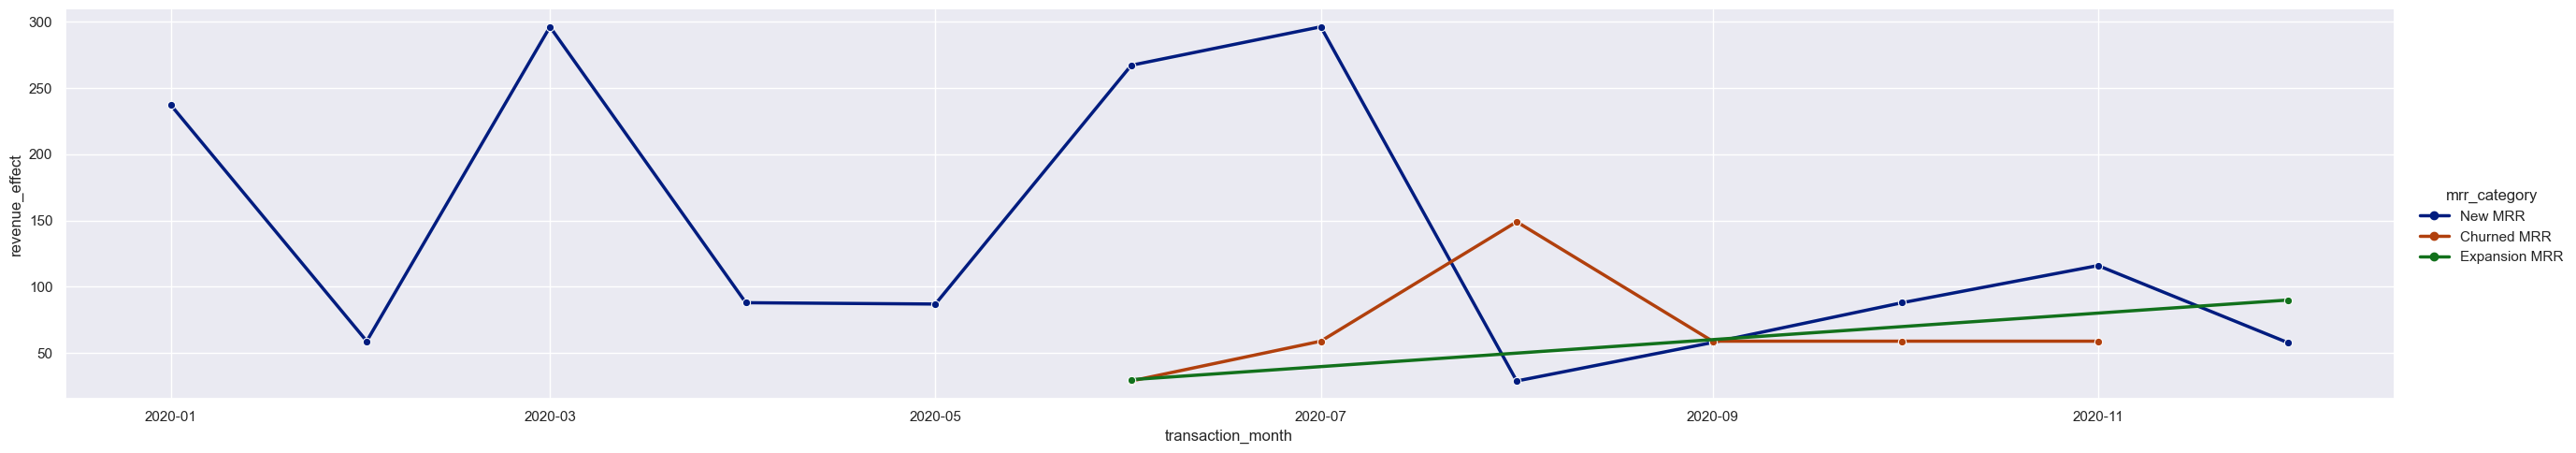

In [ ]:
mrr_2020 = mrr_2020.groupby(['transaction_month', 'mrr_category'], as_index=False)['revenue_effect'].sum()
# MRR waterfall for 2020
plt.style.use("dark_background")
sns.set_theme(style="darkgrid")
g = sns.relplot(
    data=mrr_2020,
    x='transaction_month',
    y='revenue_effect',
    hue='mrr_category',
    #col='mrr_category',
    kind='line',
    palette='dark',
    linewidth=2.5,
    marker='o',
    height=5,
    aspect=5.2
)
plt.show()

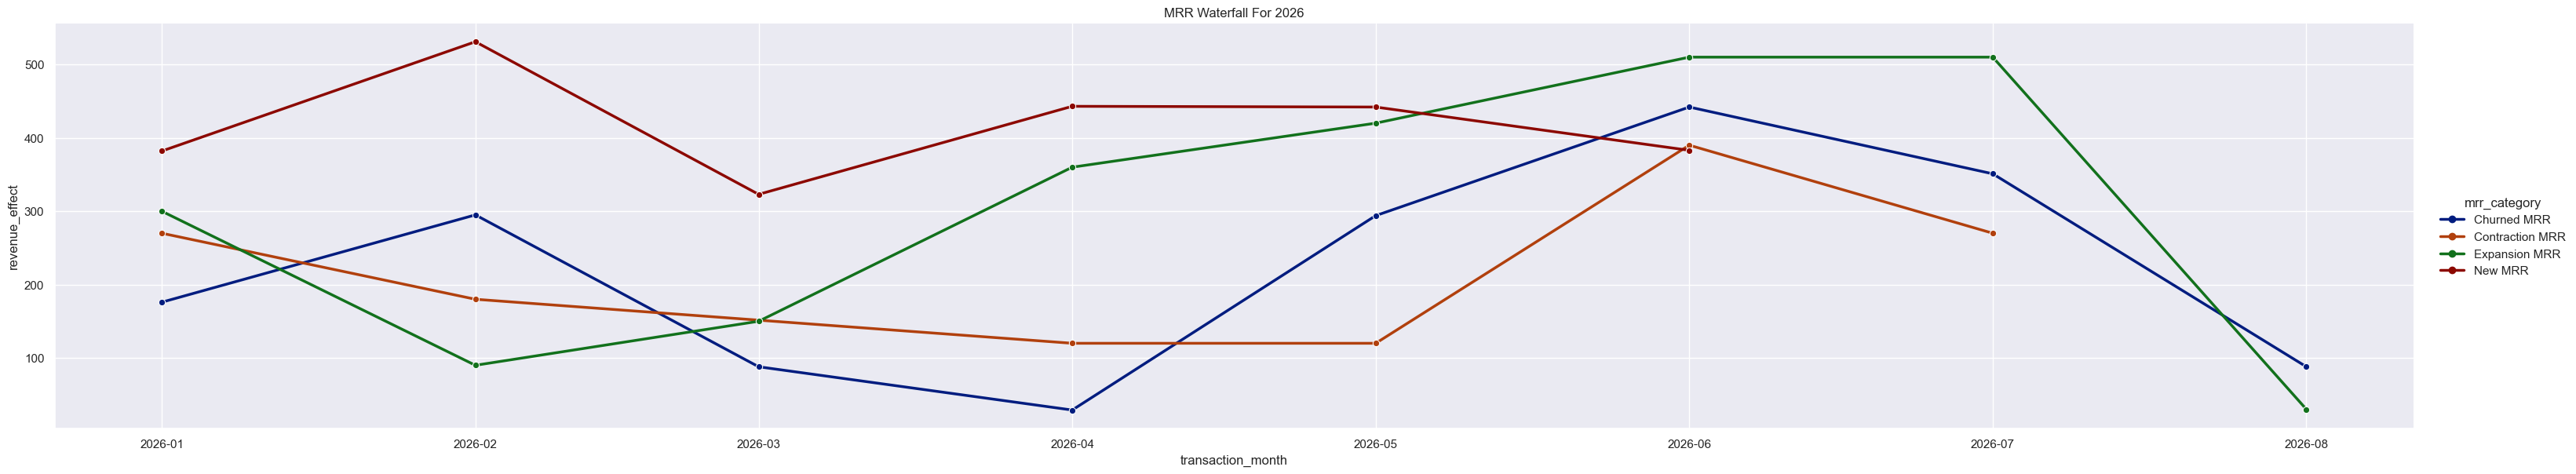

In [ ]:
# MRR waterfall for 2026
mrr_2026 = mrr_2026.groupby(['transaction_month', 'mrr_category'], as_index=False)['revenue_effect'].sum()
plt.style.use("dark_background")
sns.set_theme(style="darkgrid")
g = sns.relplot(
    data=mrr_2026,
    x='transaction_month',
    y='revenue_effect',
    hue='mrr_category',
    #col='mrr_category',
    kind='line',
    palette='dark',
    linewidth=2.5,
    marker='o',
    height=6,
    aspect=5.2
)
plt.title('MRR Waterfall For 2026')
plt.show()

In [ ]:
new_mrr = mrr_categories[mrr_categories['mrr_category'].isin(['New MRR'])]
expansion_mrr = mrr_categories[mrr_categories['mrr_category'].isin(['Expansion MRR'])]
contraction_mrr = mrr_categories[mrr_categories['mrr_category'].isin(['contraction Mrr'])]
churned_mrr = mrr_categories[mrr_categories['mrr_category'].isin(['Churned MRR'])]

In [ ]:
sns.lineplot(data=new_mrr,x='transaction_month', y= 'revenue_effect')
plt.title('Monthly Recurring Revenue for New Subscribers')
plt.xticks(rotation=45)
plt.show()

In [ ]:
sns.lineplot(data=expansion_mrr,x='transaction_month', y= 'revenue_effect')
plt.title('Monthly Recurring Revenue for Expansion Subscribers')
plt.xticks(rotation=45)
plt.show()

In [ ]:
sns.lineplot(data=contraction_mrr,x='transaction_month', y= 'revenue_effect')
plt.title('Monthly Recurring Revenue for Contraction "downgrading"')
plt.xticks(rotation=45)
plt.show()

In [ ]:
sns.lineplot(data=churned_mrr,x='transaction_month', y= 'revenue_effect')
plt.title('Monthly Recurring Revenue for churning "loose"')
plt.xticks(rotation=45)
plt.show()

## 2.Churn Rate


### A.General Churn

In [ ]:
general_churn = pd.read_sql("""WITH a as(
        SELECT
            Date_trunc('month', t.transaction_date::date)::date as transaction_month,
            CASE 
                WHEN c.final_status = 'Churned' THEN COUNT(c.customer_id)
                ELSE  0 
            END as count_churn,
            CASE 
                WHEN c.final_status = 'Active' THEN COUNT(c.customer_id)
                ELSE  0
            END as count_active
        FROM customers c
        LEFT JOIN transactions t ON c.customer_id = t.customer_id
        GROUP BY  transaction_month, c.final_status
        ORDER BY transaction_month
    ), b as(
    select
        transaction_month,
        SUM(count_churn) as churned,
        SUM(count_active) as active,
        LAG(SUM(count_active)) OVER(ORDER BY transaction_month) as prev_month_active_count
    FROM a
    GROUP BY transaction_month
)
SELECT 
    transaction_month,
    churned,
    prev_month_active_count,
    ROUND((churned / prev_month_active_count)*100,2) as churn_rate
FROM b
""",engine)
general_churn

In [ ]:
sns.lineplot(data=general_churn, x= 'transaction_month', y='churn_rate')
plt.title('The progress of general churn rate through years from 2020 till Aug 2026')
plt.xlabel('Month')
plt.ylabel('Churn Rate')
plt.show()

    as Shown above the churn rate has successfully dropped in a noticable way

### B.Packages Churn Rate

In [ ]:
package_churn = pd.read_sql("""WITH a as(
        SELECT
            Date_trunc('month', t.transaction_date::date)::date as transaction_month,
            c.initial_plan,
            CASE 
                WHEN c.final_status = 'Churned' THEN COUNT(c.customer_id)
                ELSE  0 
            END as count_churn,
            CASE 
                WHEN c.final_status = 'Active' THEN COUNT(c.customer_id)
                ELSE  0
            END as count_active
        FROM customers c
        LEFT JOIN transactions t ON c.customer_id = t.customer_id
        GROUP BY  c.initial_plan,transaction_month, c.final_status
        ORDER BY c.initial_plan
    ), b as(
    select
        transaction_month, initial_plan,
        SUM(count_churn) as churned,
        SUM(count_active) as active,
        LAG(SUM(count_active)) OVER(PARTITION BY initial_plan ORDER BY transaction_month) as prev_month_active_count
    FROM a
    GROUP BY transaction_month, initial_plan
)
SELECT 
    transaction_month, initial_plan,
    churned,
    prev_month_active_count,
    ROUND((churned / NULLIF(prev_month_active_count,0))*100,2) as churn_rate
FROM b"""
, engine
)
package_churn

In [ ]:
g = sns.relplot(
    data= package_churn,
    x= 'transaction_month',
    y= 'churn_rate',
    hue= 'initial_plan',
    kind='line',
    height=5,
    aspect= 5.5,
    palette= 'bright',
    markers='o'

)
plt.show()

    As we see from the line chart above the BASIC plan has the highest Churn rate most of years 

### C.Acqusition Channel Churn Rate

In [ ]:
channel_churn = pd.read_sql(
    """WITH a as(
        SELECT
            Date_trunc('month', t.transaction_date::date)::date as transaction_month,
            c.acquisition_channel,
            CASE 
                WHEN c.final_status = 'Churned' THEN COUNT(c.customer_id)
                ELSE  0 
            END as count_churn,
            CASE 
                WHEN c.final_status = 'Active' THEN COUNT(c.customer_id)
                ELSE  0
            END as count_active
        FROM customers c
        LEFT JOIN transactions t ON c.customer_id = t.customer_id
        GROUP BY  c.acquisition_channel,transaction_month, c.final_status
        ORDER BY c.acquisition_channel
    ), b as(
    select
        transaction_month, acquisition_channel,
        SUM(count_churn) as churned,
        SUM(count_active) as active,
        LAG(SUM(count_active)) OVER(PARTITION BY acquisition_channel ORDER BY transaction_month) as prev_month_active_count
    FROM a
    GROUP BY transaction_month, acquisition_channel
)
SELECT 
    transaction_month, acquisition_channel,
    churned,
    prev_month_active_count,
    ROUND((churned / NULLIF(prev_month_active_count,0))*100,2) as churn_rate
FROM b"""
,engine
)
channel_churn

,transaction_month,acquisition_channel,churned,prev_month_active_count,churn_rate
0,2020-01-01,Email Campaign,1.0,NaN,NaN
1,2020-02-01,Email Campaign,1.0,0.0,NaN
2,2020-03-01,Email Campaign,1.0,1.0,100.00
3,2020-04-01,Email Campaign,1.0,1.0,100.00
4,2020-05-01,Email Campaign,2.0,1.0,200.00
...,...,...,...,...,...
461,2026-04-01,Social Media,3.0,50.0,6.00
462,2026-05-01,Social Media,3.0,50.0,6.00
463,2026-06-01,Social Media,4.0,51.0,7.84
464,2026-07-01,Social Media,3.0,52.0,5.77


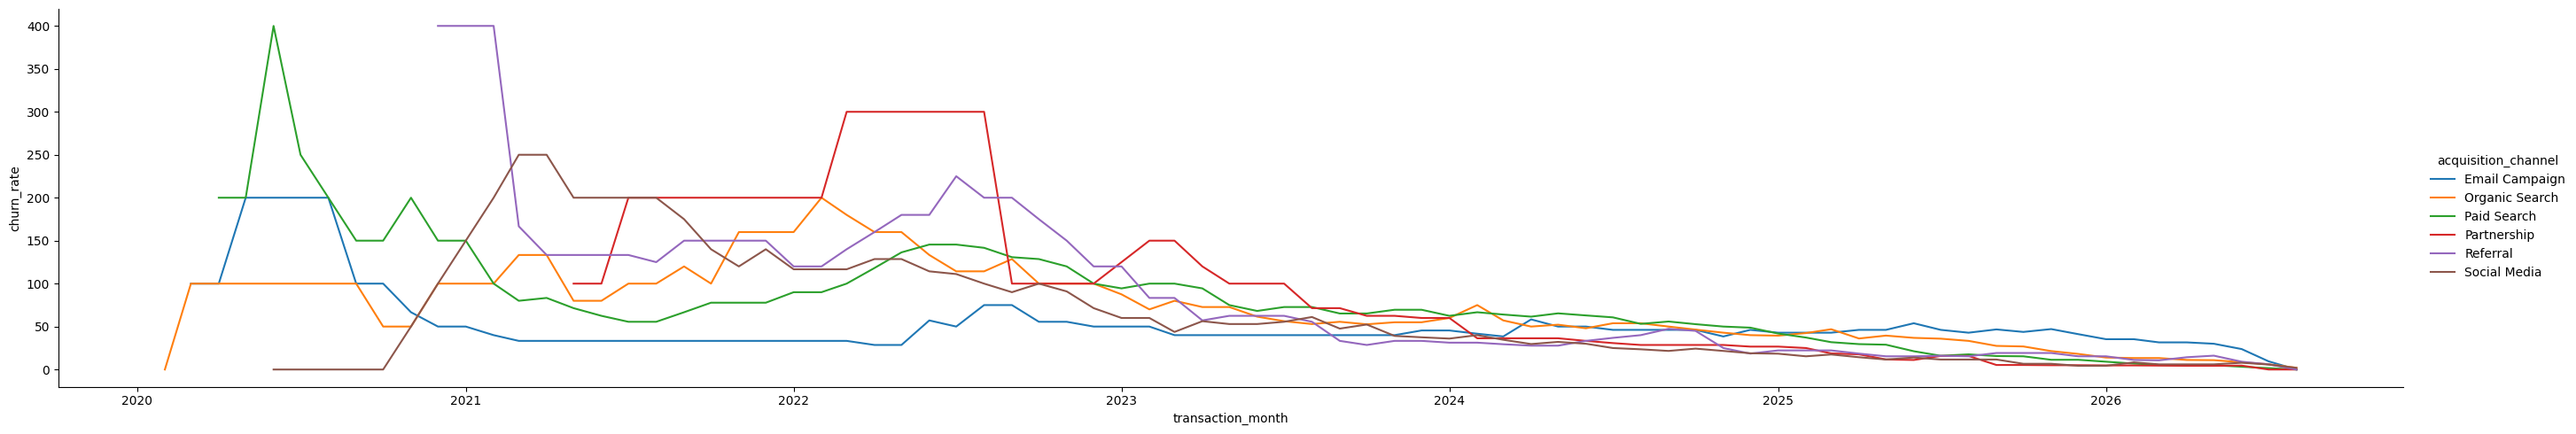

In [ ]:
g = sns.relplot(
    data=channel_churn,
    x= 'transaction_month',
    y= 'churn_rate',
    hue= 'acquisition_channel',
    kind= 'line',
    height= 5,
    aspect= 5.5
)
plt.show()

    As shown by the time we get closer to the present all the Channels getting more stable but Email Campaigns became the highest churn rate as all other aspects was decreased exept Email Campaign

## 3.CRR (Customer Retention Rate)

### A.CRR for each calender year

In [ ]:
crr_yearly = pd.read_sql(
    """WITH a as(
    SELECT
        t.customer_id,
        TO_CHAR(t.transaction_date::date,'YYYY') as transaction_year,
        TO_CHAR(c.first_churn_date::date,'YYYY') as churn_year

    FROM transactions t 
    LEFT JOIN customers c ON t.customer_id = c.customer_id
), b as(
    SELECT
        transaction_year,
        COUNT(DISTINCT CASE 
        WHEN churn_year IS DISTINCT FROM transaction_year THEN customer_id
        END) as active_at_end
    FROM a
    GROUP BY transaction_year
    ORDER BY transaction_year
),c as(
    SELECT b.*,
        LAG(active_at_end) OVER(ORDER BY transaction_year) as active_at_began
    FROM b
),d as(
    SELECT
        TO_CHAR(signup_date::date, 'YYYY') as signup_year,
        COUNT(customer_id) as new_customers
    FROM customers
    GROUP BY signup_year
),e as(
    SELECT
        c.*,
        d.new_customers
    FROM d LEFT JOIN c ON signup_year = transaction_year
)
SELECT
    transaction_year as year,
    ROUND(((active_at_end - new_customers)::numeric / NULLIF(active_at_began,0)) * 100,2) as CRR
FROM e
ORDER BY year"""
,engine
)
crr_yearly

,year,crr
0,2020,NaN
1,2021,83.33
2,2022,69.23
3,2023,77.14
4,2024,78.21
5,2025,73.27
6,2026,90.63


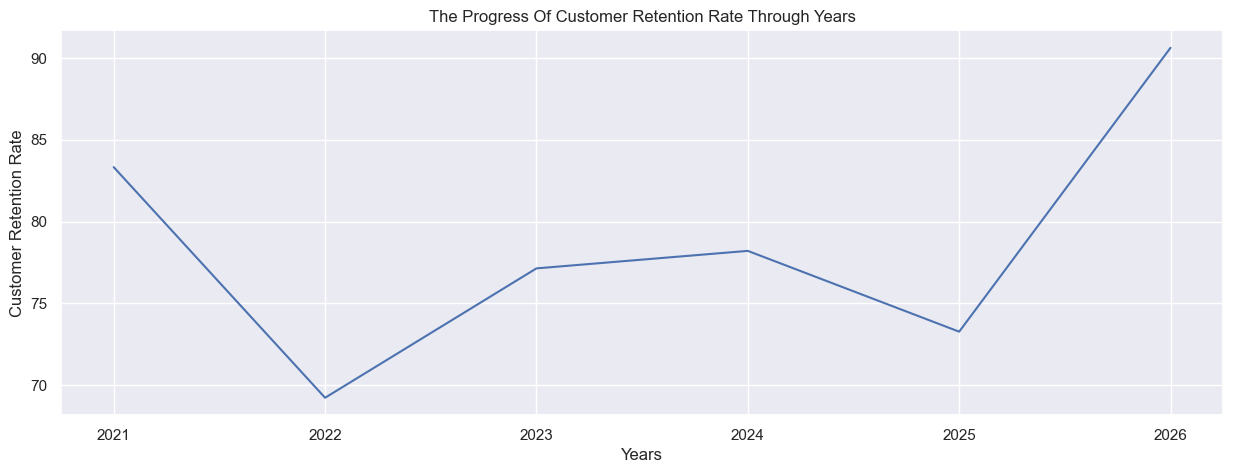

In [ ]:
plt.figure(figsize=(15,5))
sns.lineplot(data= crr_yearly, x= 'year', y= 'crr')
plt.title('The Progress Of Customer Retention Rate Through Years')
plt.ylabel('Customer Retention Rate')
plt.xlabel('Years')
plt.show()

### B. CRR for each region for each year

In [ ]:
crr_region = pd.read_sql(
    """
WITH a as(
    SELECT
        c.region,
        t.customer_id,
        TO_CHAR(t.transaction_date::date,'YYYY') as transaction_year,
        TO_CHAR(c.first_churn_date::date,'YYYY') as churn_year

    FROM transactions t 
    LEFT JOIN customers c ON t.customer_id = c.customer_id
)
, b as(
    SELECT
        region,
        transaction_year,
        COUNT(DISTINCT CASE 
        WHEN churn_year IS DISTINCT FROM transaction_year THEN customer_id
        END) as active_at_end
    FROM a
    GROUP BY region, transaction_year
    ORDER BY transaction_year
)
,c as(
    SELECT b.*,
        LAG(active_at_end) OVER(PARTITION BY region ORDER BY transaction_year) as active_at_began
    FROM b
)
,d as(
    SELECT
        region,
        TO_CHAR(signup_date::date, 'YYYY') as signup_year,
        COUNT(customer_id) as new_customers
    FROM customers
    GROUP BY region, signup_year
)
,e as(
    SELECT
        c.*,
        d.new_customers
    FROM c LEFT JOIN d ON signup_year = transaction_year AND d.region = c.region
)
SELECT
    region,
    transaction_year as year,
    ROUND(((active_at_end - new_customers)::numeric / NULLIF(active_at_began,0)) * 100,2) as CRR
FROM e
ORDER BY year

""",engine
)


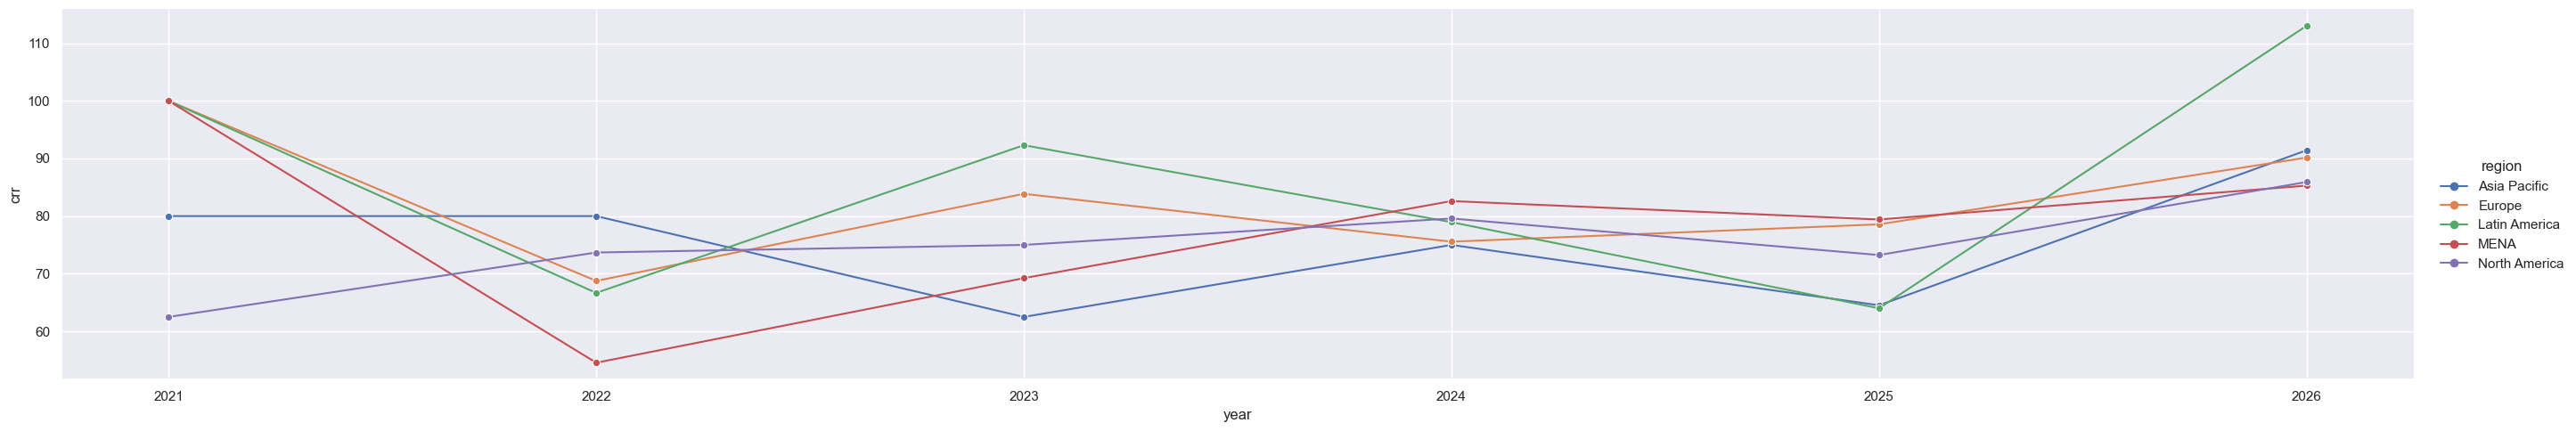

In [ ]:
g = sns.relplot(
    data= crr_region,
    x= 'year',
    y= 'crr',
    hue= 'region',
    kind= 'line',
    height= 5,
    aspect= 5.5,
    marker= 'o'
)
plt.show()

## 4.GRR (Gross Revenue Retention)

In [ ]:
grr_first_year = pd.read_sql(
    """WITH cohort as(
        SELECT 
            customer_id,
            Date_Trunc('month', signup_date)::DATE as cohort_month
        FROM customers
        WHERE Date_Trunc('month', signup_date)::DATE = '2024-02-01'
), b as(
SELECT
        cohort.customer_id,
        Date_Trunc('month', t.transaction_date)::DATE as transaction_month,
        t.transaction_type,
        t.amount,
        FIRST_VALUE(amount) OVER(PARTITION BY customer_id 
        ORDER BY Date_Trunc('month', t.transaction_date)::DATE) as starting_mrr,
        LAG(amount) OVER(PARTITION BY customer_id ORDER BY t.transaction_date) as prev_month
    FROM transactions t
    INNER JOIN cohort USING (customer_id)
    where Date_Trunc('month', t.transaction_date)::DATE <= cohort_month + INTERVAL '1year'
), c as(
    
    SELECT
        
        MAX(starting_mrr) as starting_mrr,
        SUM(CASE WHEN transaction_type = 'Cancellation' THEN prev_month ELSE 0 END) as churn_amount ,
        SUM(CASE WHEN transaction_type = 'Downgrade' THEN prev_month - amount ELSE 0 END) as contraction_amount
    from b
    GROUP BY customer_id
)
SELECT
    SUM(starting_mrr) as mrr,
     SUM(churn_amount) as churn,
     SUM(contraction_amount) as contraction,
    ROUND((SUM(starting_mrr) - SUM(churn_amount) - SUM(contraction_amount)):: NUMERIC / SUM(starting_mrr),2) as GRR
FROM c"""
,engine
)
grr_first_year

,mrr,churn,contraction,grr
0,410.0,235.0,0.0,0.43


    Gross Revenue Retention for the first year is 43%.
    however, the sample is so small "only 10 customers" on the cohort so we will need more investigation regarding a more accurate or trusted GRR

In [ ]:
grr_second_year = pd.read_sql(
    """
WITH cohort as(
        SELECT 
            customer_id,
            Date_Trunc('month', signup_date)::DATE as cohort_month
        FROM customers
        WHERE Date_Trunc('month', signup_date)::DATE = '2024-02-01'
), b as(
SELECT
        cohort.customer_id,
        Date_Trunc('month', t.transaction_date)::DATE as transaction_month,
        t.transaction_type,
        t.amount,
        FIRST_VALUE(amount) OVER(PARTITION BY customer_id 
        ORDER BY Date_Trunc('month', t.transaction_date)::DATE) as starting_mrr,
        LAG(amount) OVER(PARTITION BY customer_id ORDER BY t.transaction_date) as prev_month
    FROM transactions t
    INNER JOIN cohort USING (customer_id)
    where Date_Trunc('month', t.transaction_date)::DATE >= cohort_month + INTERVAL '1year'
    AND Date_Trunc('month', t.transaction_date)::DATE <= cohort_month + INTERVAL '2year'
), c as(

    SELECT
        
        MAX(starting_mrr) as starting_mrr,
        SUM(CASE WHEN transaction_type = 'Cancellation' THEN prev_month ELSE 0 END) as churn_amount ,
        SUM(CASE WHEN transaction_type = 'Downgrade' THEN prev_month - amount ELSE 0 END) as contraction_amount
    from b
    GROUP BY customer_id
)
SELECT
    SUM(starting_mrr) as mrr,
     SUM(churn_amount) as churn,
     SUM(contraction_amount) as contraction,
    ROUND((SUM(starting_mrr) - SUM(churn_amount) - SUM(contraction_amount)):: NUMERIC / SUM(starting_mrr),2) as GRR
FROM c"""
,engine)
grr_second_year

,mrr,churn,contraction,grr
0,354.0,118.0,0.0,0.67


    Gross Revenue Retention for the first year is 67%.
    however, the sample is so small "only 10 customers" on the cohort so we will need more investigation regarding a more accurate or trusted GRR

## 5. NRR (Net Revenue Retention)

In [ ]:
nrr = pd.read_sql(
    """WITH cohort as(
        SELECT 
            customer_id,
            Date_Trunc('quarter', signup_date)::DATE as cohort_quarter
        FROM customers
        WHERE Date_Trunc('quarter', signup_date)::DATE = '2024-01-01'
), b as ( /*for first year*/
    SELECT
        cohort.customer_id,
        cohort_quarter,
        Date_Trunc('quarter', t.transaction_date)::DATE as transaction_quarter,
        t.transaction_type,
        t.amount,
        FIRST_VALUE(amount) OVER(PARTITION BY customer_id 
        ORDER BY Date_Trunc('quarter', t.transaction_date)::DATE) as starting_mrr,
        LAG(amount) OVER(PARTITION BY customer_id ORDER BY t.transaction_date) as prev_quarter
    FROM transactions t
    INNER JOIN cohort USING (customer_id)
    where Date_Trunc('quarter', t.transaction_date)::DATE BETWEEN '2024-01-01' AND '2024-10-01'
), c
as( /*for first year*/
    SELECT
        cohort_quarter,
        Date_Trunc('year',transaction_quarter)::DATE as year,
        MAX(starting_mrr) as starting_mrr,
        SUM(CASE WHEN transaction_type = 'Cancellation' THEN prev_quarter ELSE 0 END) as churn_amount ,
        SUM(CASE WHEN transaction_type = 'Downgrade' THEN prev_quarter - amount ELSE 0 END) as contraction_amount,
        SUM(CASE WHEN transaction_type = 'Upgrade' THEN amount - prev_quarter ELSE 0 END) as expanion_amount
    from b
    GROUP BY customer_id,cohort_quarter,year
), d as( /*for second year*/
    SELECT
        cohort_quarter,
        cohort.customer_id,
        Date_Trunc('quarter', t.transaction_date)::DATE as transaction_quarter,
        t.transaction_type,
        t.amount,
        FIRST_VALUE(amount) OVER(PARTITION BY customer_id 
        ORDER BY Date_Trunc('quarter', t.transaction_date)::DATE) as starting_mrr,
        LAG(amount) OVER(PARTITION BY customer_id ORDER BY t.transaction_date) as prev_quarter
    FROM transactions t
    INNER JOIN cohort USING (customer_id)
    where Date_Trunc('quarter', t.transaction_date)::DATE BETWEEN '2025-01-01' AND '2025-10-01'
), e as( /*for second year*/
    SELECT
        cohort_quarter,
        customer_id,
        Date_Trunc('year',transaction_quarter)::DATE as year,
        MAX(starting_mrr) as starting_mrr,
        SUM(CASE WHEN transaction_type = 'Cancellation' THEN prev_quarter ELSE 0 END) as churn_amount ,
        SUM(CASE WHEN transaction_type = 'Downgrade' THEN prev_quarter - amount ELSE 0 END) as contraction_amount,
        SUM(CASE WHEN transaction_type = 'Upgrade' THEN amount - prev_quarter ELSE 0 END) as expanion_amount
    from d
    GROUP BY cohort_quarter,customer_id,year
), f as(
    /*for_first_year*/
SELECT
    
    MAX(year) as year,
    SUM(starting_mrr) as mrr,
     SUM(churn_amount) as churn,
     SUM(contraction_amount) as contraction,
     SUM(expanion_amount) as expansion,
    ROUND((SUM(starting_mrr) - SUM(churn_amount) - SUM(contraction_amount) + SUM(expanion_amount)):: NUMERIC / SUM(starting_mrr),2) as NRR
FROM c
), g as(
    /*for second year*/
SELECT
    
    MAX(year) as year,
    SUM(starting_mrr) as mrr,
     SUM(churn_amount) as churn,
     SUM(contraction_amount) as contraction,
     SUM(expanion_amount) as expansion,
    ROUND((SUM(starting_mrr) - SUM(churn_amount) - SUM(contraction_amount) + SUM(expanion_amount)):: NUMERIC / SUM(starting_mrr),2) as NRR
FROM e
)

SELECT
    'Year 1' as period,
    f.mrr, f.churn, f.contraction, f.expansion, f.NRR
FROM f

UNION ALL

SELECT
    'Year 2' as period,
    g.mrr, g.churn, g.contraction, g.expansion, g.NRR
FROM g
"""
,engine
)
nrr

,period,mrr,churn,contraction,expansion,nrr
0,Year 1,822.0,325.0,0.0,300.0,0.97
1,Year 2,768.0,177.0,90.0,30.0,0.69


    as we see the there is a drop in the NRR for the second year due to downgrading despite the drop in churn rate.

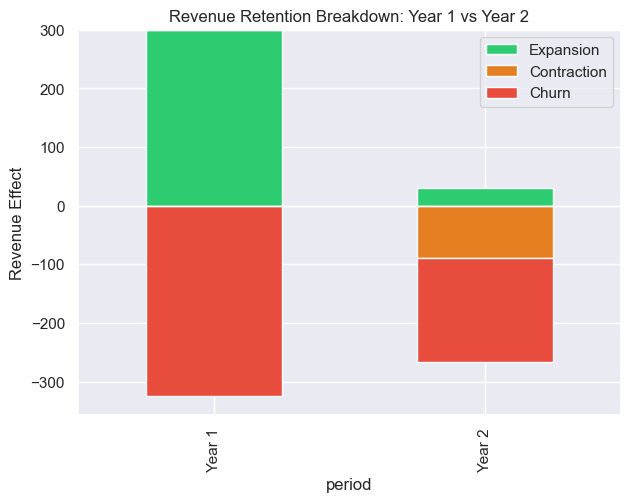

In [ ]:

sns.set_theme(style="darkgrid")

df = pd.DataFrame({
    'period': ['Year 1', 'Year 2'],
    'Expansion':   [300, 30],
    'Contraction': [0, -90],     
    'Churn':       [-325, -177], 
})

df.set_index('period')[['Expansion', 'Contraction', 'Churn']].plot(
    kind='bar', stacked=True, figsize=(7, 5),
    color=['#2ecc71', '#e67e22', '#e74c3c']
)
plt.axhline(0, color='white', linewidth=1)
plt.ylabel('Revenue Effect')
plt.title('Revenue Retention Breakdown: Year 1 vs Year 2')
plt.show()

## 6.ARPU (Average Revenue Per User)

### ARPU for the whole customers base for each Quarter

In [13]:
arpu_whole = pd.read_sql(
    """WITH a as(
    SELECT 
        
        CAST(DATE_TRUNC('quarter', CAST(transaction_date AS date)) AS date) AS quarter,
        COUNT(DISTINCT customer_id) AS num_customers,
        ROUND(SUM(amount), 2) AS total_amount
    FROM transactions
    WHERE amount > 0
    GROUP BY quarter
)
    SELECT
        quarter,
        ROUND(total_amount::numeric /num_customers,2) as ARPU
    FROM a""",engine
)
arpu_whole.head()

,quarter,arpu
0,2020-01-01,140.63
1,2020-04-01,155.13
2,2020-07-01,170.24
3,2020-10-01,146.23
4,2021-01-01,146.00


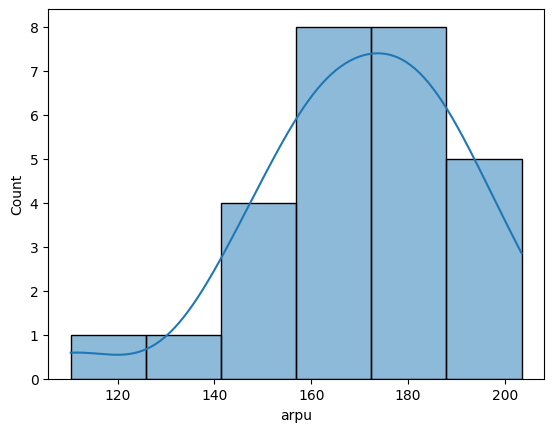

In [28]:
sns.histplot(
    arpu_whole,
    x= 'arpu',
    kde= True
    )
plt.show()

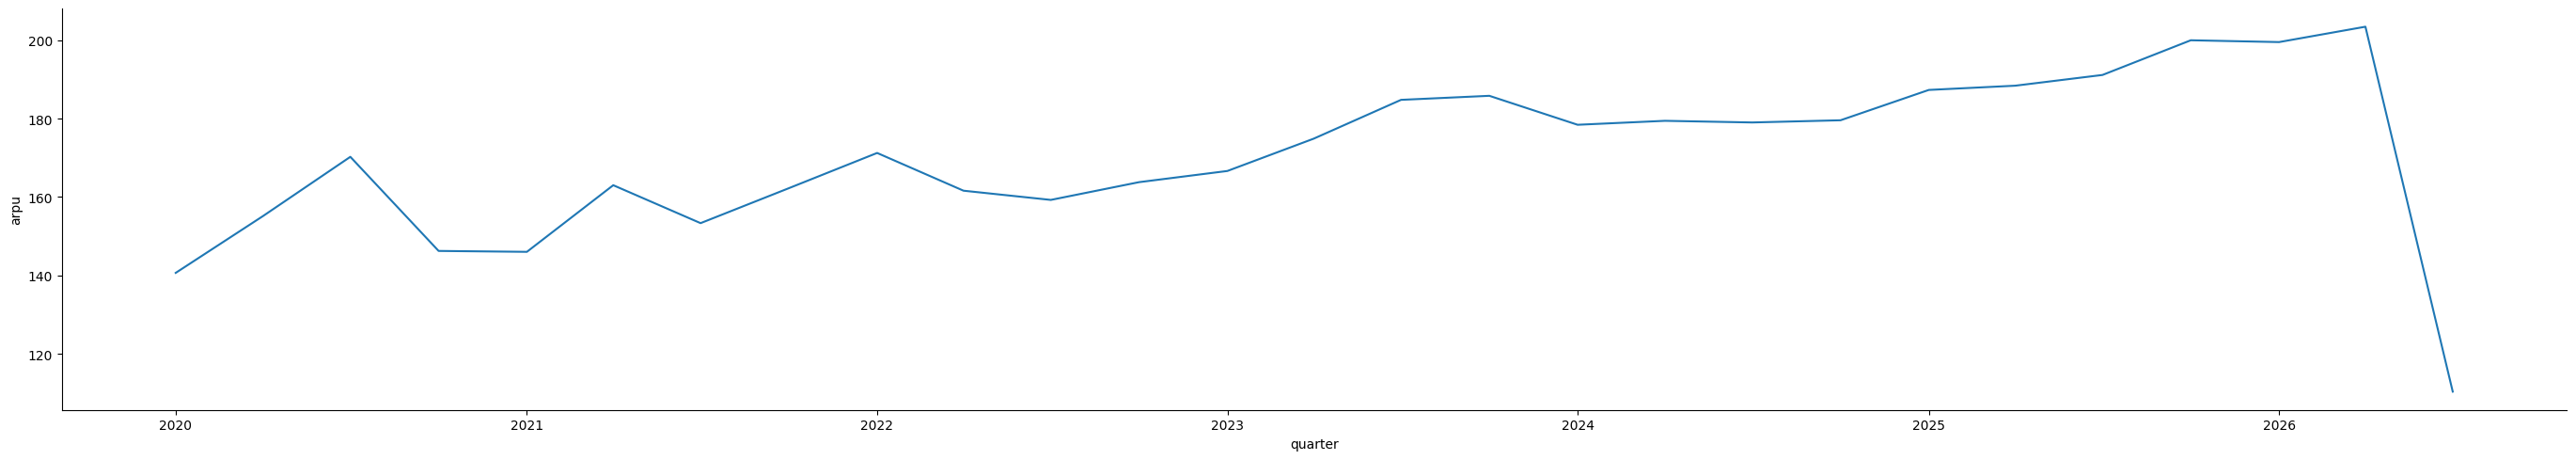

In [17]:
g = sns.relplot(
    data=arpu_whole,
    kind= 'line',
    x='quarter',
    y= 'arpu',
    markers= 'x',
    height= 5,
    aspect= 5.5
)
plt.show()

    as we can observe, there is a slight progress in the ARPU with time, small progress but still progress

### ARPU by Plan Tier

In [18]:
arpu_plan = pd.read_sql(
    """WITH a as(
    SELECT 
        plan_tier,
        CAST(DATE_TRUNC('quarter', CAST(transaction_date AS date)) AS date) AS quarter,
        COUNT(DISTINCT customer_id) AS num_customers,
        ROUND(SUM(amount), 2) AS total_amount
    FROM transactions
    WHERE amount > 0
    GROUP BY quarter, plan_tier
)
    SELECT
        plan_tier,
        quarter,
        ROUND(total_amount::numeric /num_customers,2) as ARPU
    FROM a
    ORDER BY plan_tier, quarter""", engine
)
arpu_plan.head()

,plan_tier,quarter,arpu
0,Basic,2020-01-01,58.00
1,Basic,2020-04-01,62.83
2,Basic,2020-07-01,68.88
3,Basic,2020-10-01,71.53
4,Basic,2021-01-01,77.33


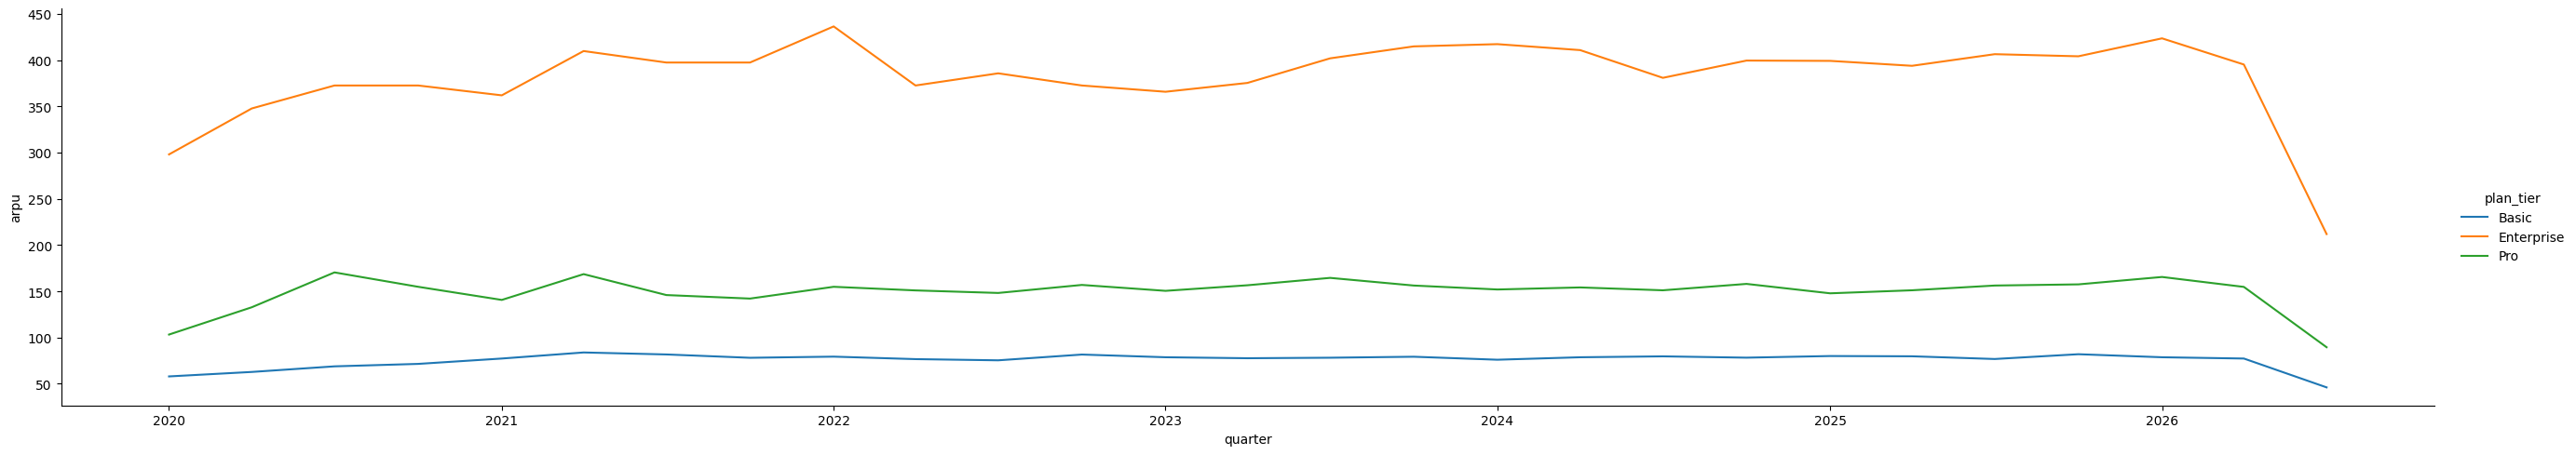

In [19]:
g = sns.relplot(
    data=arpu_plan,
    x= 'quarter',
    y= 'arpu',
    hue= 'plan_tier',
    kind= 'line',
    height= 5,
    aspect=5.3,
    markers= 'o'
)
plt.show()

    as an observation, the Enterprise plan has the best impact over ARPU and the Basic plan has the least

### ARPU by Region (Important for Marketing)

In [20]:
arpu_region = pd.read_sql(
    """WITH a as(
    SELECT 
        c.region,
        CAST(DATE_TRUNC('quarter', CAST(t.transaction_date AS date)) AS date) AS quarter,
        COUNT(DISTINCT t.customer_id) AS num_customers,
        ROUND(SUM(t.amount), 2) AS total_amount
    FROM transactions t 
    LEFT JOIN customers c 
    ON t.customer_id = c.customer_id
    WHERE amount > 0
    GROUP BY quarter, region
)
    SELECT
        region,
        quarter,
        ROUND(total_amount::numeric /num_customers,2) as ARPU
    FROM a
    ORDER BY region, quarter""",engine
)
arpu_region.head()

,region,quarter,arpu
0,Asia Pacific,2020-01-01,118.00
1,Asia Pacific,2020-04-01,171.20
2,Asia Pacific,2020-07-01,167.17
3,Asia Pacific,2020-10-01,147.40
4,Asia Pacific,2021-01-01,147.00


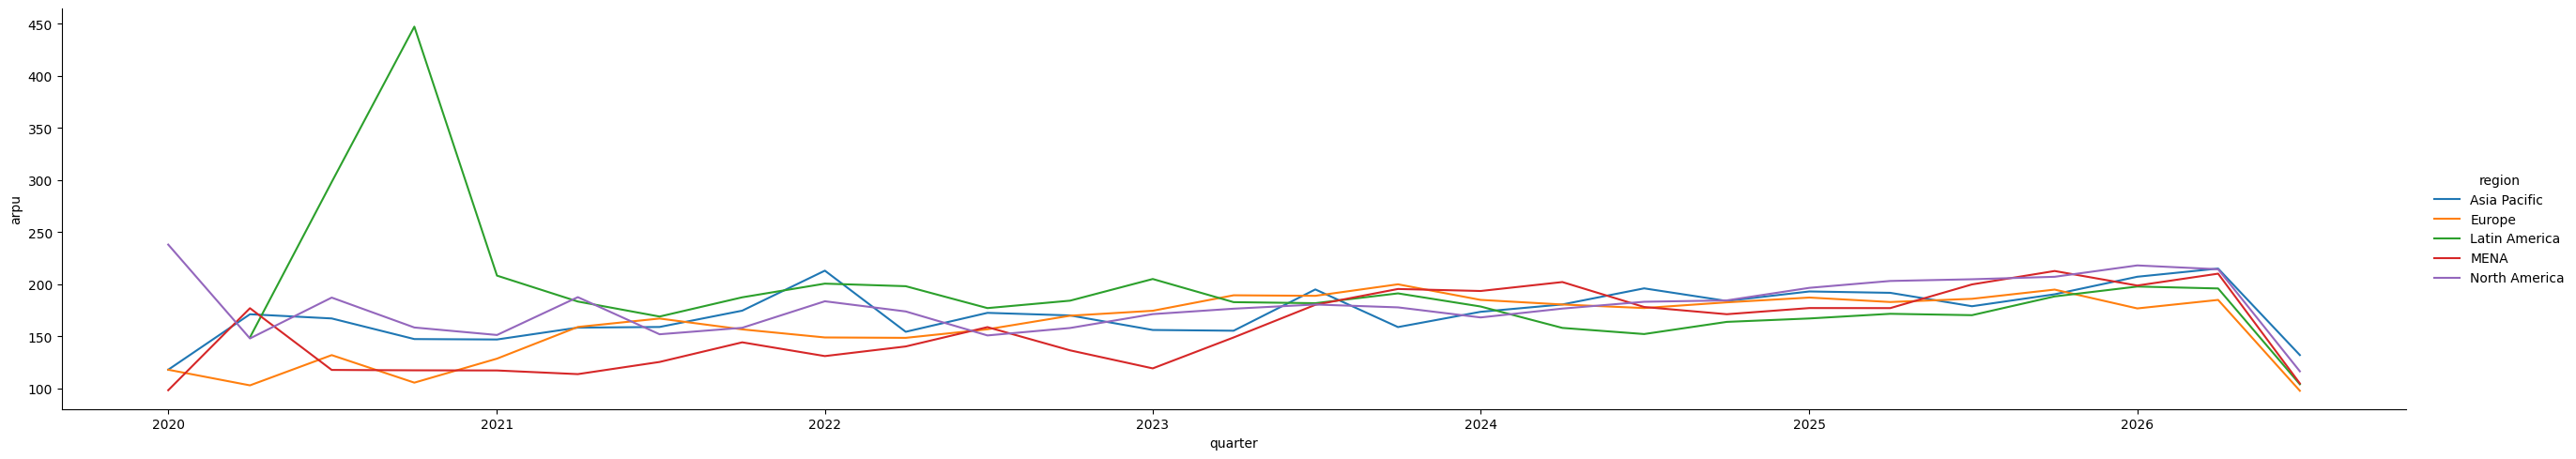

In [23]:
g = sns.relplot(
    data=arpu_region,
    x= 'quarter',
    y=  'arpu',
    hue= 'region',
    kind='line',
    height=5,
    aspect=5.2,
    markers='x'
)
plt.show()

    as we see North America has more stable ARPU, however, Latin America has an extreemly high ARPU within 2020 which needs more investigates

## 7.CAC (Customer Acquisition Cost)


### CAC per each Channel for every year

In [34]:
cac_channel = pd.read_sql(
    """WITH a as(
    SELECT 
        acquisition_channel,
        Date_Trunc('year', signup_date::date)::date as year,
        COUNT(customer_id) as new_customers,
        ROUND(SUM(acquisition_cost)::numeric,2) as total_spent
    FROM customers
    GROUP BY year, acquisition_channel
    ORDER BY acquisition_channel, year
)
SELECT 
    acquisition_channel,
    year,
    ROUND((total_spent / new_customers),2) as CAC
FROM a
""", engine
)
cac_channel.sample(5)

,acquisition_channel,year,cac
3,Email Campaign,2023-01-01,60.66
13,Organic Search,2026-01-01,26.70
39,Social Media,2024-01-01,88.84
9,Organic Search,2022-01-01,12.19
2,Email Campaign,2022-01-01,47.67


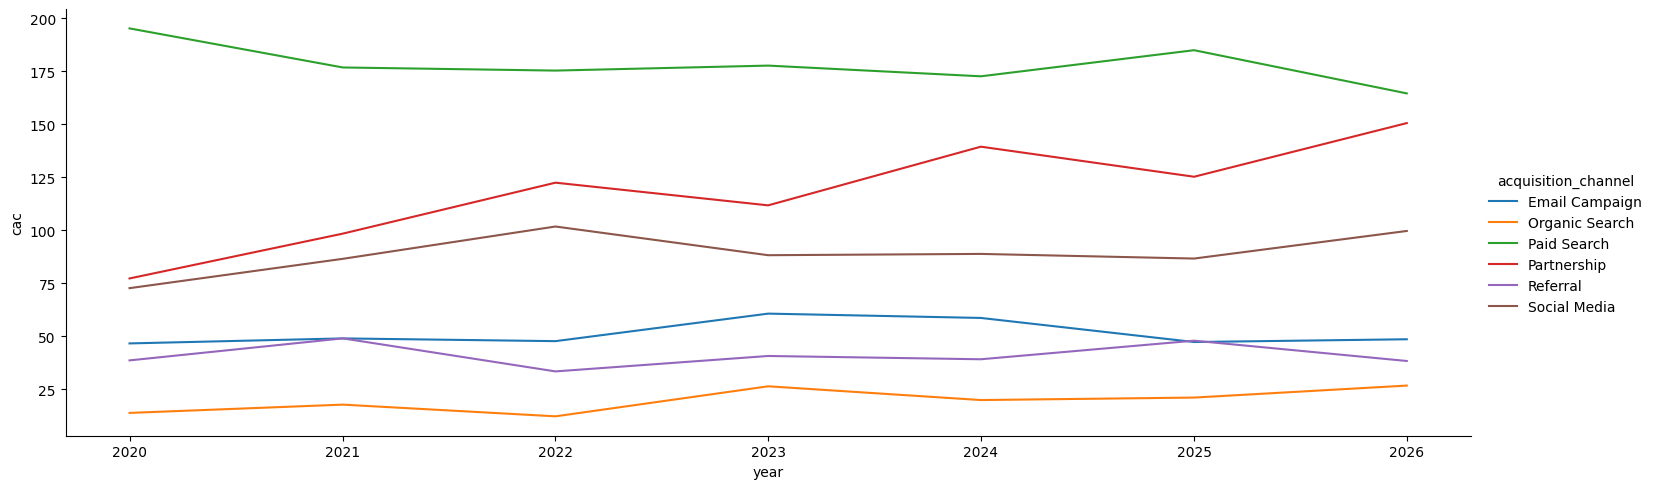

In [39]:
sns.relplot(
    data=cac_channel,
    x='year',
    y='cac',
    kind='line',
    markers='o',
    hue='acquisition_channel',
    aspect=3
)
plt.show()

## 8.CLTV (Customer Lifetime Value)